DC-preserved HMF


Metric                     Original     Filtered           Δ
──────────────────────────────────────────────────────────────
Michelson contrast           0.7374       1.0000     +0.2626
RMS contrast                 0.0523       0.1030     +0.0506
Shannon entropy              5.4436       6.4310     +0.9874
Mean local entropy           3.0887       4.5005     +1.4117
Laplacian variance           7.1319      95.9409    +88.8090


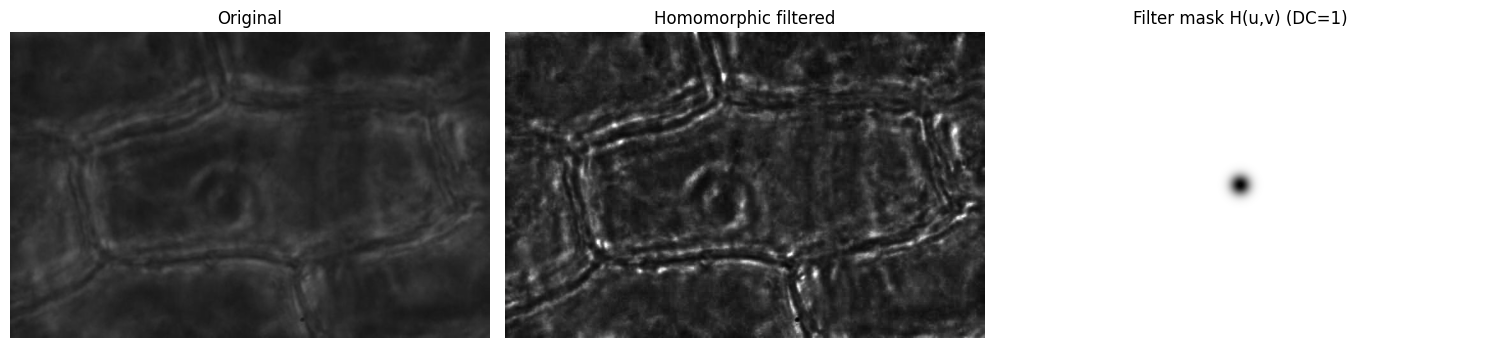

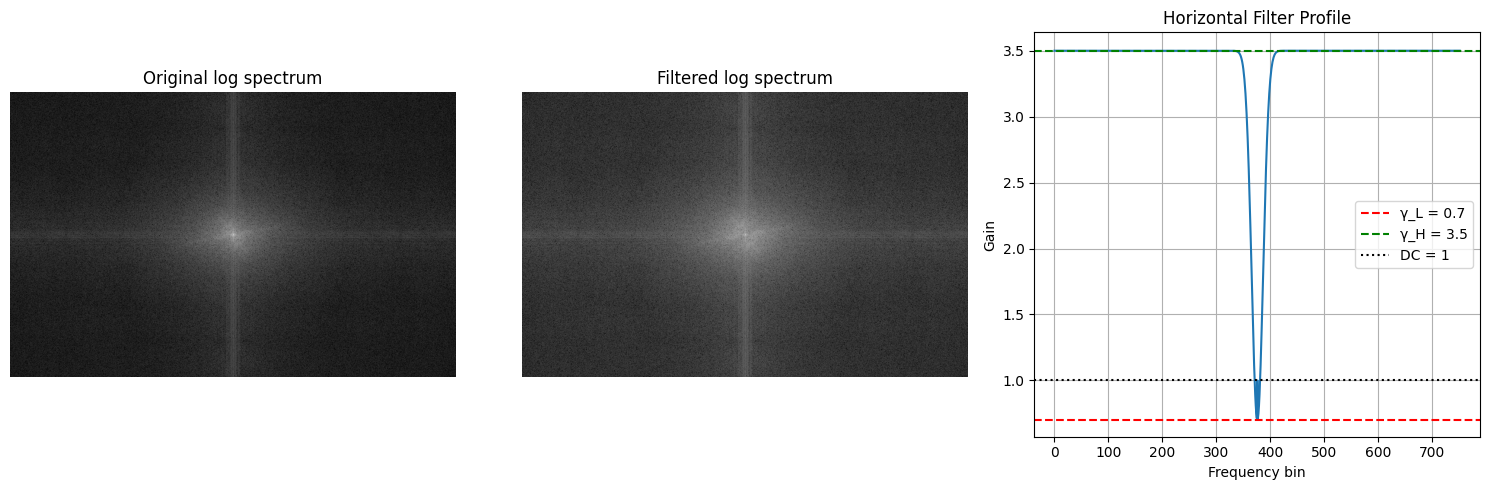

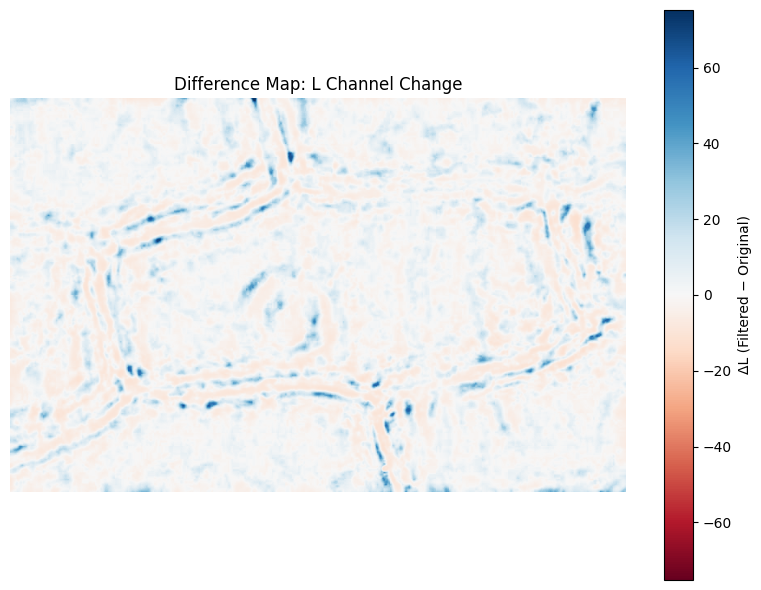

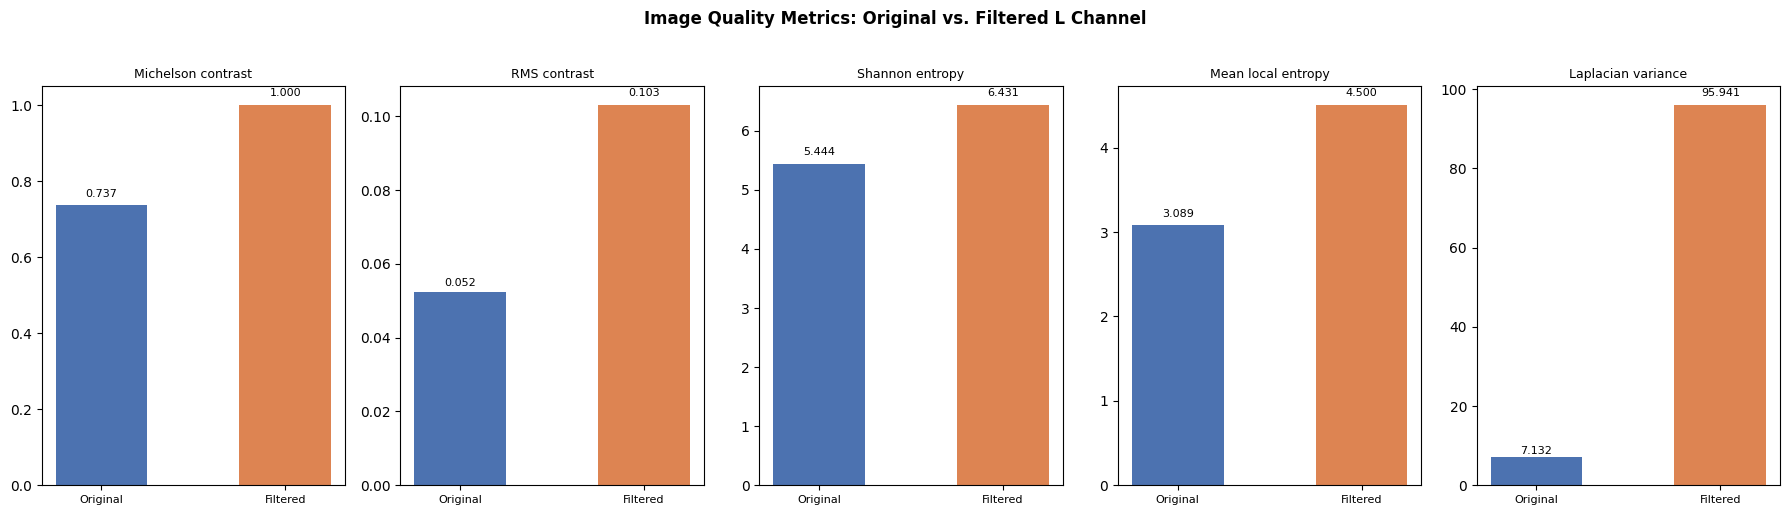

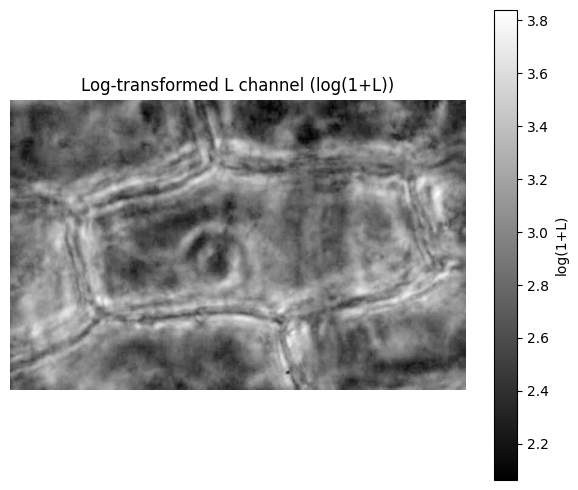

<Figure size 640x480 with 0 Axes>

In [ ]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import cv2
from skimage.measure import shannon_entropy
from skimage.filters.rank import entropy as local_entropy
from skimage.morphology import disk

# Load image
img = Image.open("/content/1.jpg").convert('RGB')
img_np = np.array(img)

# Convert to LAB (L in [0,100])
img_float = img_np.astype(np.float32) / 255.0
lab = cv2.cvtColor(img_float, cv2.COLOR_RGB2LAB)
L = lab[:, :, 0].copy()

# Log-domain transform
gray_log = np.log1p(L)

# FFT
fft = np.fft.fftshift(np.fft.fft2(gray_log))
rows, cols = gray_log.shape
crow, ccol = rows // 2, cols // 2
y, x = np.ogrid[:rows, :cols]
distance = np.sqrt((x - ccol)**2 + (y - crow)**2)

# Filter parameters
D0      = 15
gamma_L = 0.7
gamma_H = 3.5
c       = 1

homomorphic_filter = (gamma_H - gamma_L) * \
                     (1 - np.exp(-c * distance**2 / D0**2)) + gamma_L

# ────────────────────────────────────
# FIX: keep average brightness unchanged
homomorphic_filter[crow, ccol] = 1.0
# ────────────────────────────────────

filtered_fft = fft * homomorphic_filter
filtered_log = np.real(np.fft.ifft2(np.fft.ifftshift(filtered_fft)))

# Inverse log, NO min‑max stretch
filtered_L = np.clip(np.expm1(filtered_log), 0, 100)   # <-- fix 1

# Rebuild LAB → RGB, save as PNG (lossless)
lab_out = lab.copy()
lab_out[:, :, 0] = filtered_L
result_rgb = cv2.cvtColor(lab_out, cv2.COLOR_LAB2RGB)
result_rgb = np.clip(result_rgb * 255, 0, 255).astype(np.uint8)
Image.fromarray(result_rgb).save("HMF_1_yH_3_5.png")   # <-- fix 2

# ────────────────────────────────────
# Metrics on unstretched, [0,1] scaled data
L_norm        = L           / 100.0
filtered_norm = filtered_L / 100.0

def compute_metrics(channel):
    cmin, cmax = channel.min(), channel.max()
    michelson  = (cmax - cmin) / (cmax + cmin + 1e-8)
    rms        = float(channel.std())

    # FIX: Convert to uint8 first, then run Shannon Entropy on the discrete bins
    ch_u8      = (channel * 255).astype(np.uint8)
    shannon    = float(shannon_entropy(ch_u8))

    loc_ent    = local_entropy(ch_u8, disk(5))
    mean_local = float(loc_ent.mean())
    lap        = cv2.Laplacian(ch_u8, cv2.CV_64F)
    lap_var    = float(lap.var())
    return dict(michelson_contrast=michelson,
                rms_contrast=rms,
                shannon_entropy=shannon,
                mean_local_entropy=mean_local,
                laplacian_variance=lap_var)

metrics_orig = compute_metrics(L_norm)
metrics_filt = compute_metrics(filtered_norm)

# Print table (3 columns: original, filtered, delta)
labels = {
    "michelson_contrast" : "Michelson contrast",
    "rms_contrast"       : "RMS contrast",
    "shannon_entropy"    : "Shannon entropy",
    "mean_local_entropy" : "Mean local entropy",
    "laplacian_variance" : "Laplacian variance",
}
print(f"\n{'Metric':<22} {'Original':>12} {'Filtered':>12}  {'Δ':>10}")
print("─" * 62)
for key, name in labels.items():
    o, f = metrics_orig[key], metrics_filt[key]
    print(f"{name:<22} {o:>12.4f} {f:>12.4f}  {f-o:>+10.4f}")

# ────────────────────────────────────
# Figure 1 – Image comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 6))
axes[0].imshow(img_np)
axes[0].set_title("Original")
axes[0].axis('off')
axes[1].imshow(result_rgb)
axes[1].set_title("Homomorphic filtered")
axes[1].axis('off')
axes[2].imshow(homomorphic_filter, cmap='gray')
axes[2].set_title("Filter mask H(u,v) (DC=1)")
axes[2].axis('off')
plt.tight_layout()
plt.show()

# Figure 2 – Frequency spectra
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(np.log1p(np.abs(fft)), cmap='gray')
axes[0].set_title("Original log spectrum")
axes[0].axis('off')
axes[1].imshow(np.log1p(np.abs(filtered_fft)), cmap='gray')
axes[1].set_title("Filtered log spectrum")
axes[1].axis('off')
profile = homomorphic_filter[crow, :]
axes[2].plot(profile)
axes[2].axhline(gamma_L, color='r', linestyle='--', label=f'γ_L = {gamma_L}')
axes[2].axhline(gamma_H, color='g', linestyle='--', label=f'γ_H = {gamma_H}')
axes[2].axhline(1.0, color='k', linestyle=':', label='DC = 1')
axes[2].set_title("Horizontal Filter Profile")
axes[2].set_xlabel("Frequency bin")
axes[2].set_ylabel("Gain")
axes[2].legend()
axes[2].grid(True)
plt.tight_layout()
# -------------------- SAVE FFT LOG SPECTRUM IMAGE --------------------
plt.savefig("fft_log_spectrum.png", bbox_inches='tight', dpi=150)
# ---------------------------------------------------------------------
plt.show()

# Figure 3 – Difference map (where did the filter act?)
diff = filtered_L - L
plt.figure(figsize=(8, 6))
plt.imshow(diff, cmap='RdBu', vmin=-np.abs(diff).max(), vmax=np.abs(diff).max())
plt.colorbar(label='ΔL (Filtered − Original)')
plt.title("Difference Map: L Channel Change")
plt.axis('off')
plt.tight_layout()
# -------------------- SAVE DIFFERENCE MAP --------------------
plt.savefig("difference_map.png", bbox_inches='tight', dpi=150)
# ------------------------------------------------------------
plt.show()

# Figure 4 – Metrics bar chart
fig, axes = plt.subplots(1, 5, figsize=(18, 5))
colors = ['#4C72B0', '#DD8452']
for ax, (key, name) in zip(axes, labels.items()):
    vals = [metrics_orig[key], metrics_filt[key]]
    bars = ax.bar(['Original', 'Filtered'], vals, color=colors, width=0.5)
    ax.set_title(name, fontsize=9, pad=6)
    ax.tick_params(axis='x', labelsize=8)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8)
plt.suptitle("Image Quality Metrics: Original vs. Filtered L Channel",
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()

# Display the log-transformed L channel
plt.figure(figsize=(6, 5))
plt.imshow(gray_log, cmap='gray')
plt.title("Log-transformed L channel (log(1+L))")
plt.colorbar(label='log(1+L)')
plt.axis('off')
plt.tight_layout()
plt.show()
plt.savefig("log_transformed_l_channel.png", bbox_inches='tight', dpi=150)

# -------------------- SAVE METRICS BAR CHART --------------------
plt.savefig("metrics_barchart.png", bbox_inches='tight', dpi=150)
# ----------------------------------------------------------------
plt.show()

Metric vs parameters for six images

Saved: /content/metric_plots/metrics_vs_D0.png


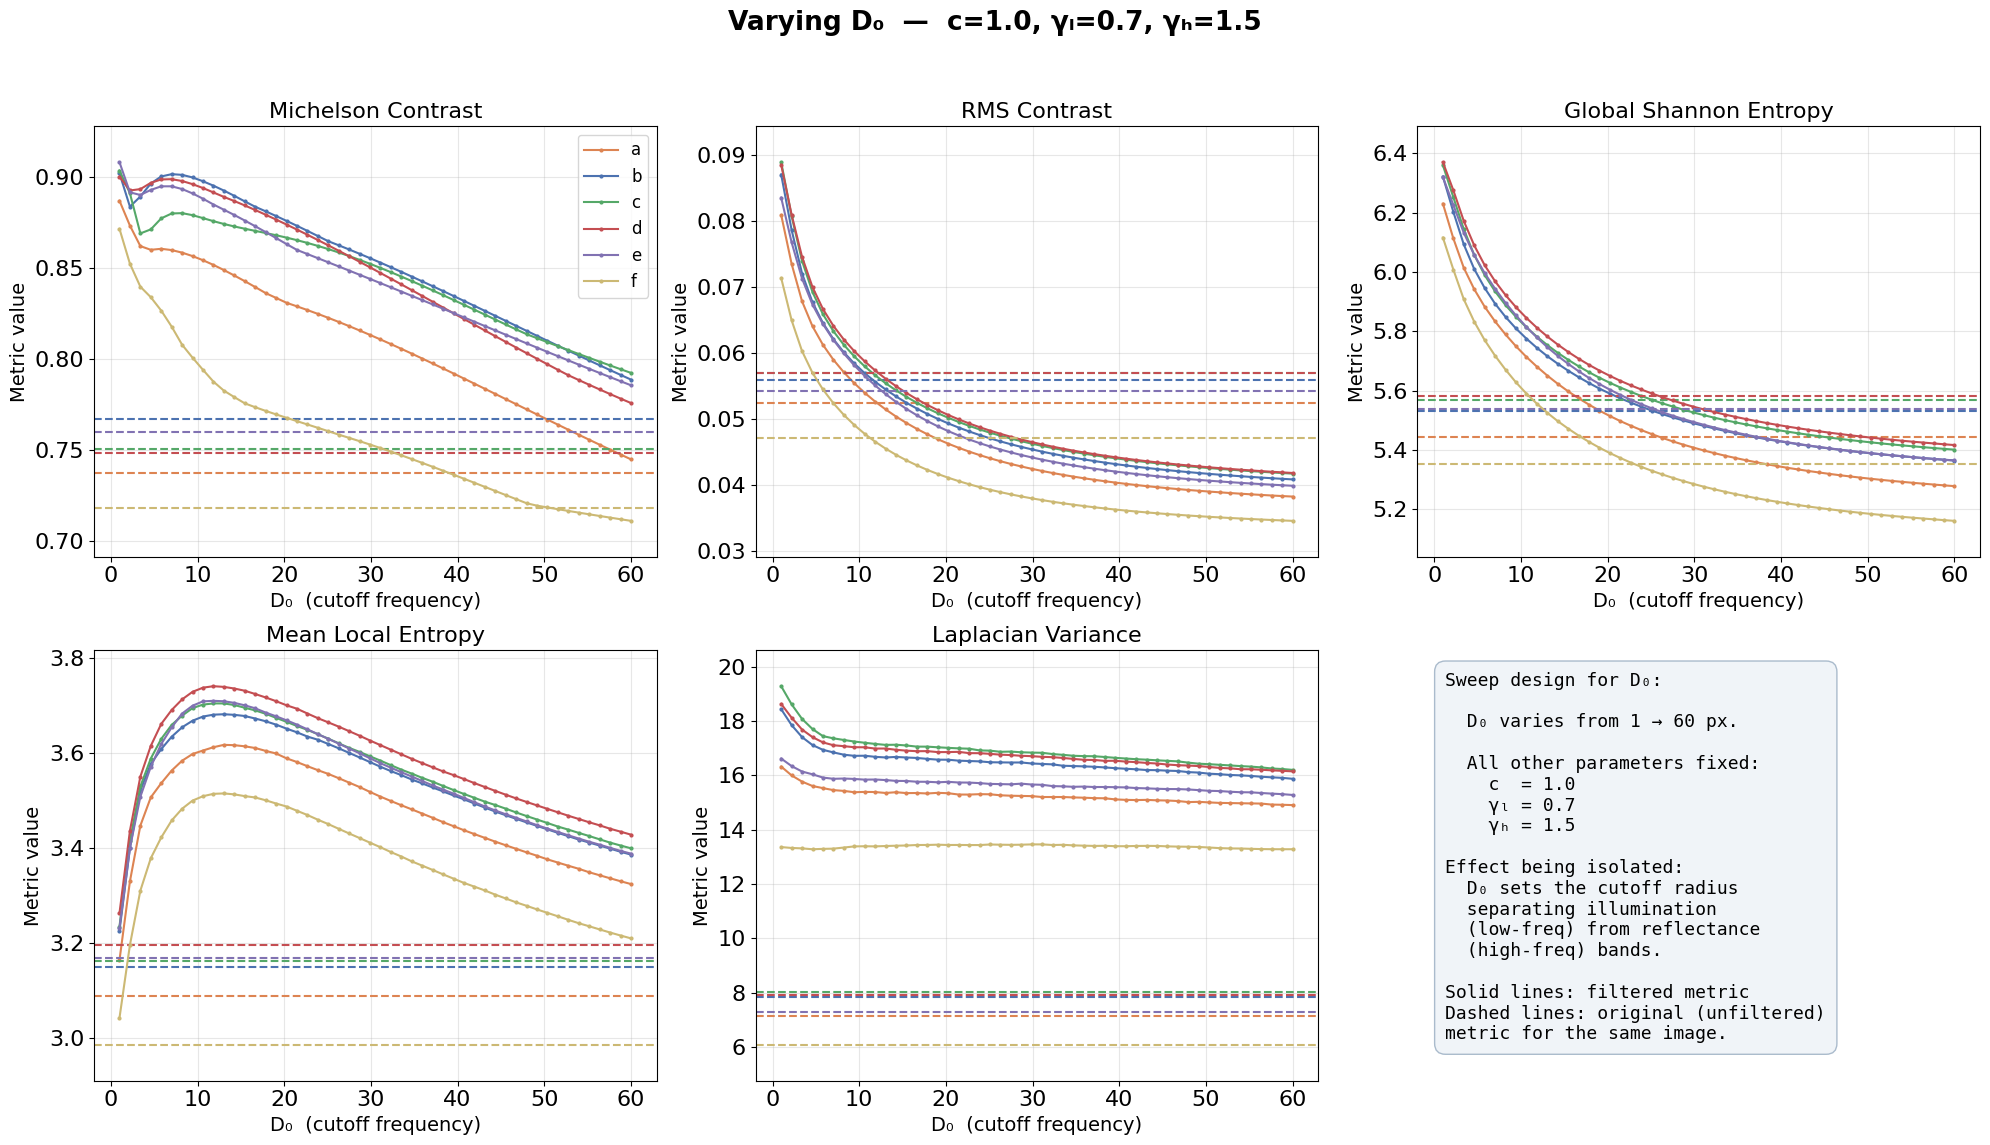

Saved: /content/metric_plots/metrics_vs_gamma_H.png


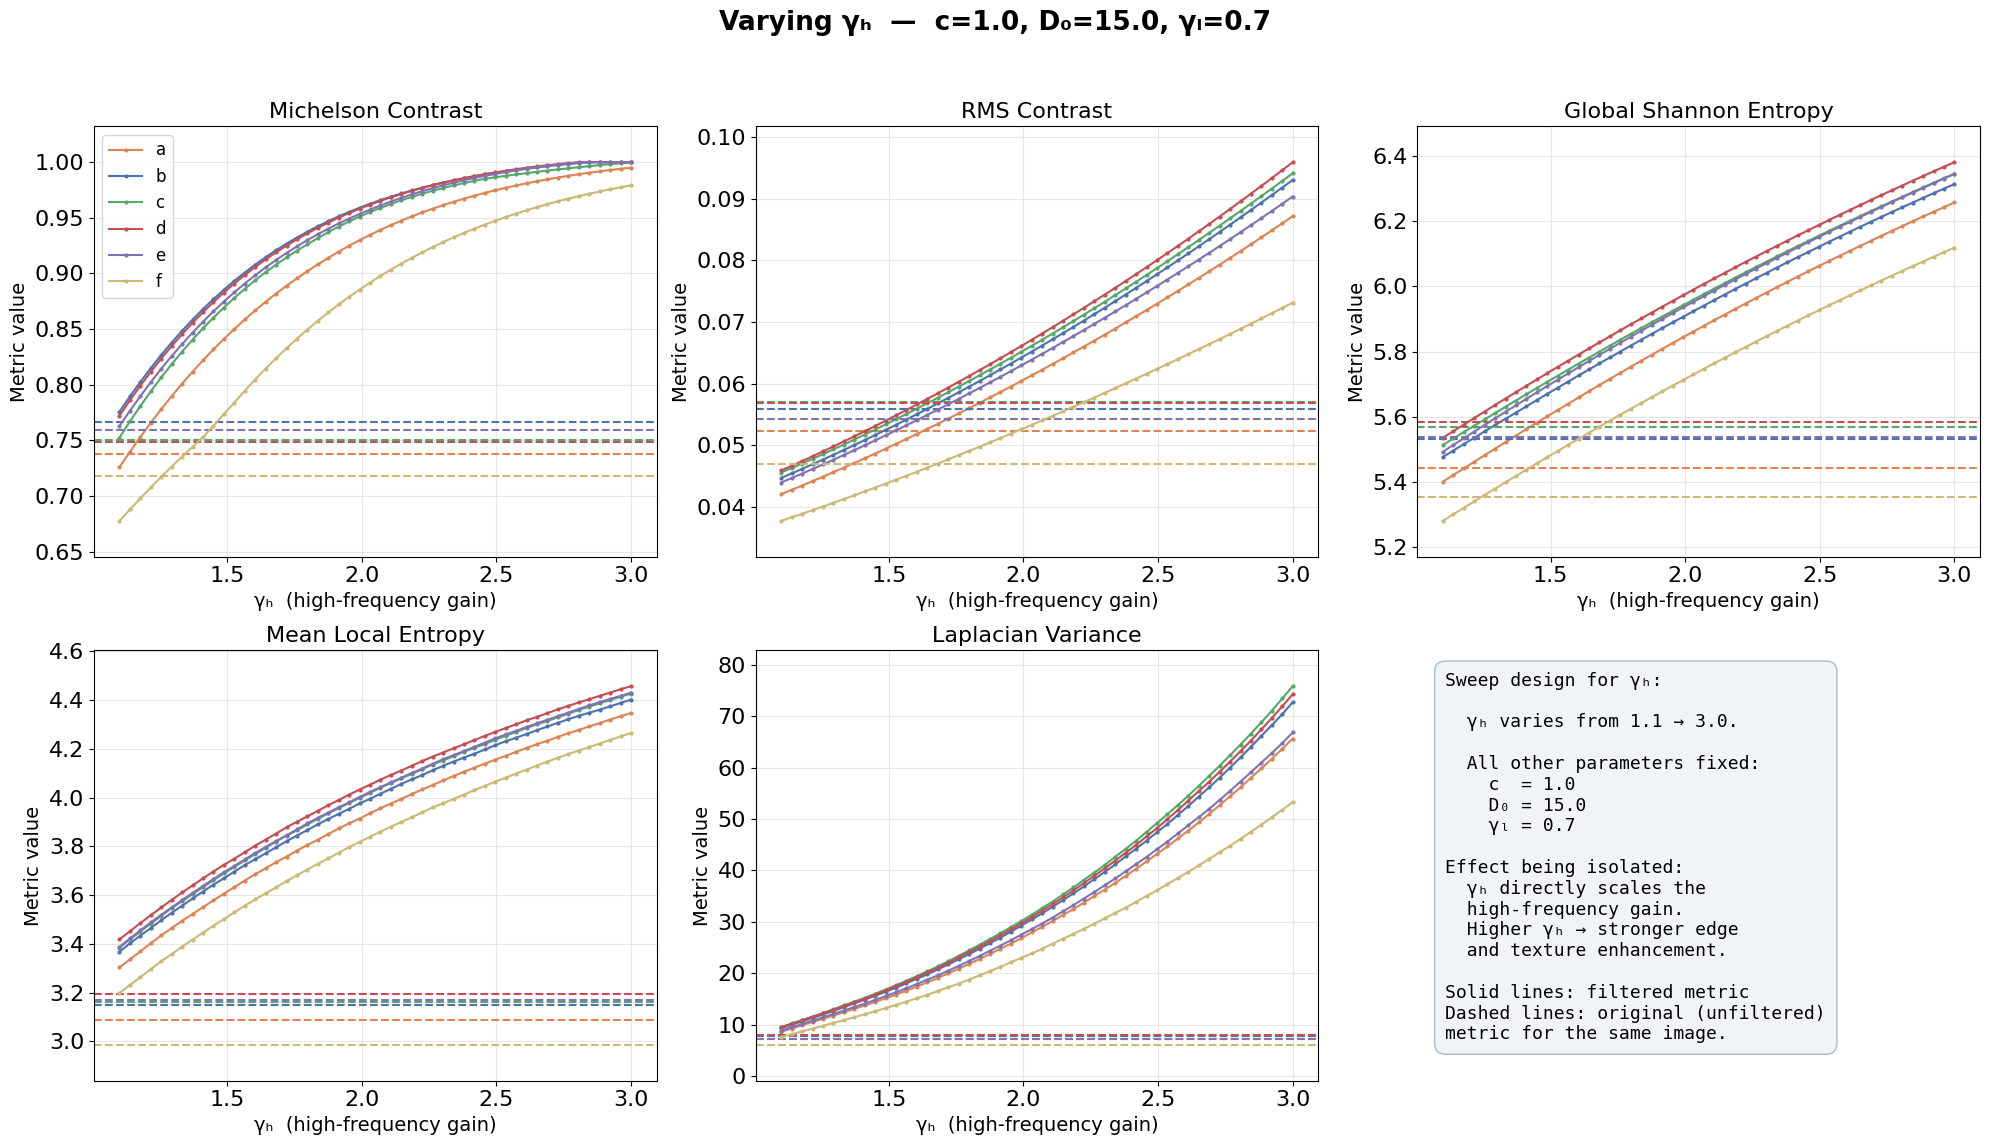

Saved: /content/metric_plots/metrics_vs_gamma_L.png


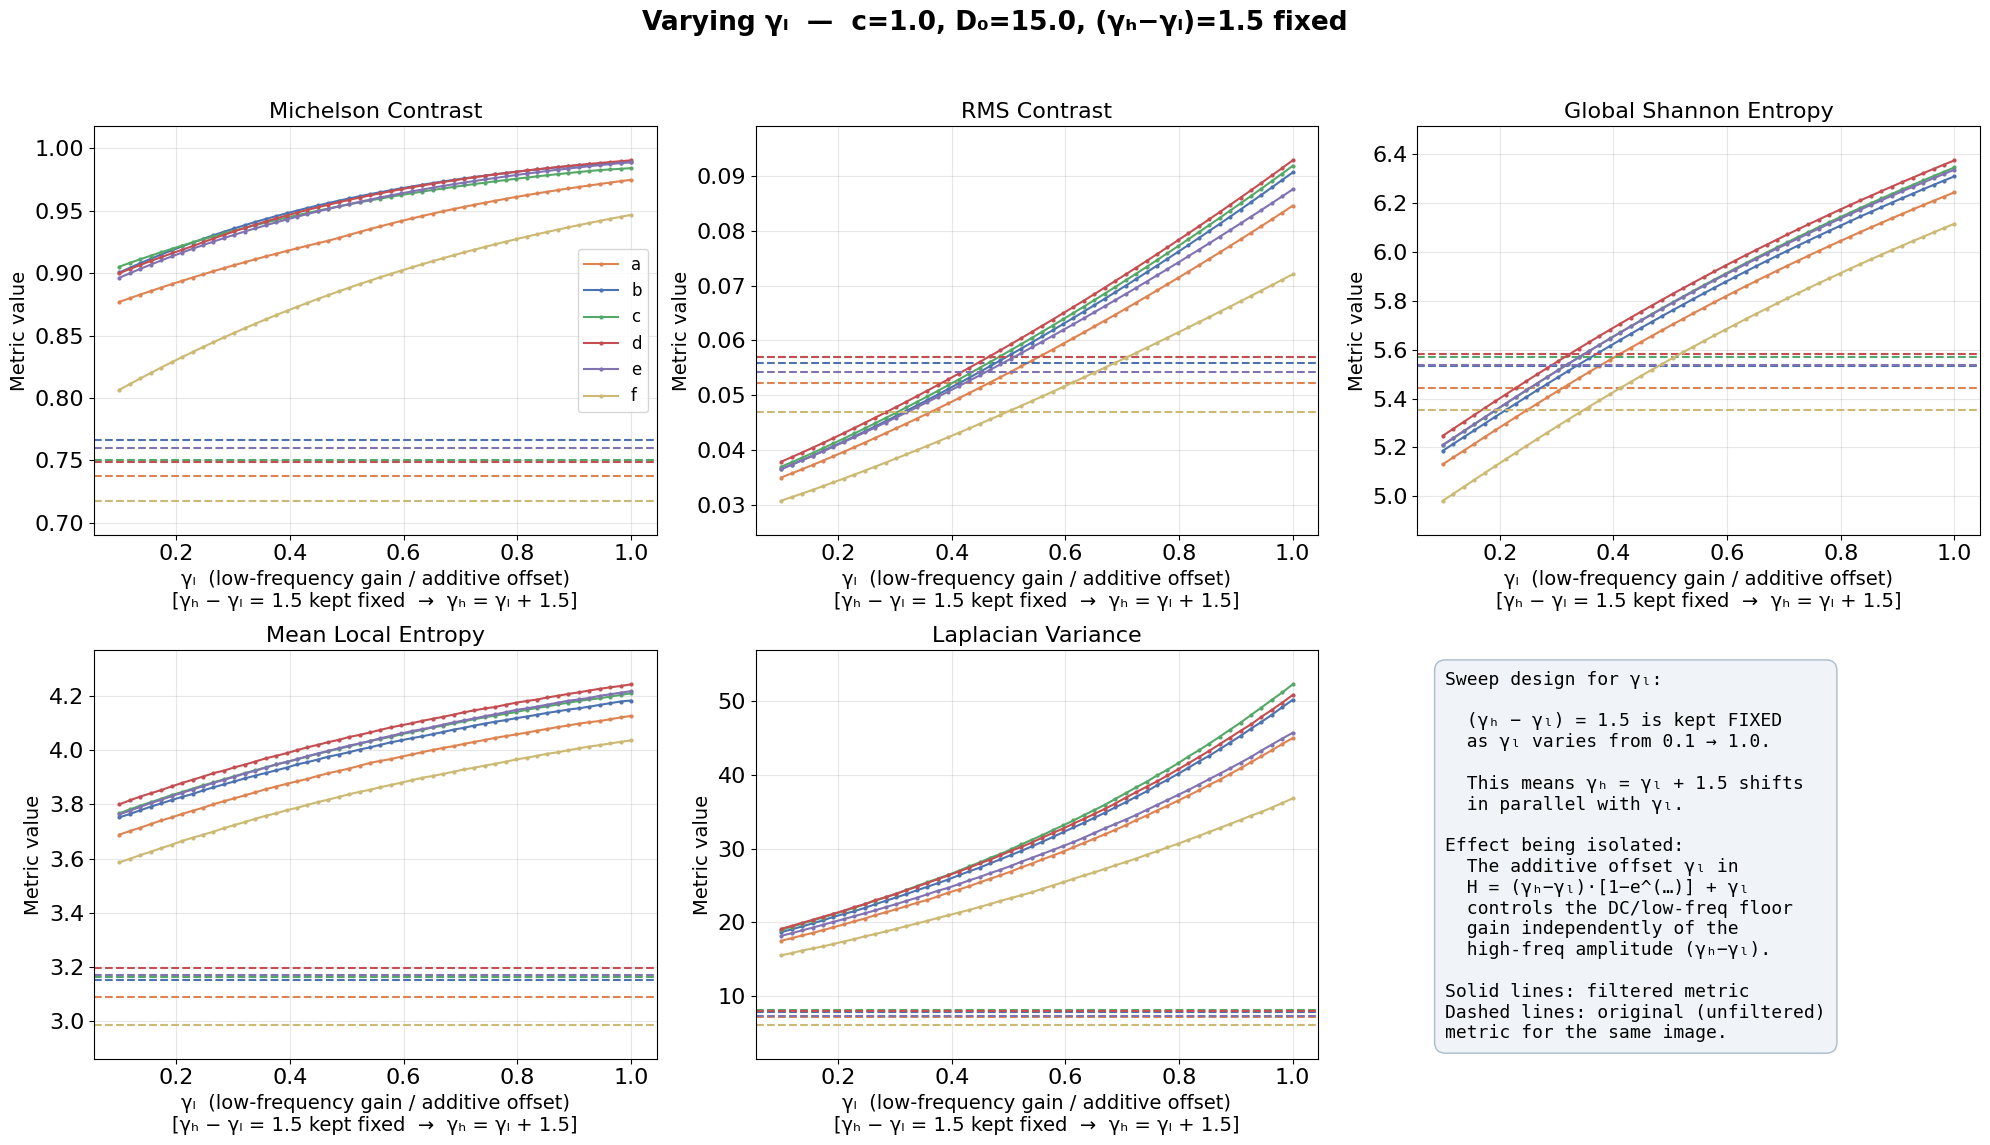


All figures saved in: /content/metric_plots
Fixed parameter across all sweeps:  c = 1.0
Baseline values:  D₀=15.0, γₗ=0.7, γₕ=1.5, Δ(γₕ−γₗ)=1.5


In [ ]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import cv2
from skimage.measure import shannon_entropy
from skimage.filters.rank import entropy as local_entropy
from skimage.morphology import disk

# ============================================================
# Create output directory for figures
# ============================================================
save_dir = "/content/metric_plots"
os.makedirs(save_dir, exist_ok=True)

# ============================================================
# 1. List of six image paths – ADJUST THESE TO YOUR FILES
# ============================================================
image_paths = [
    "/content/a",
    "/content/b",
    "/content/c",
    "/content/d",
    "/content/e",
    "/content/f",
]

# Colour for each image (first image = orange, as in the original code)
colors = ['#DD8452', '#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974']
if len(image_paths) > len(colors):   # fallback if more than six images
    colors = plt.cm.tab10(np.linspace(0, 1, len(image_paths)))
    colors[0] = '#DD8452'            # keep first orange

# ============================================================
# 2. Metric computation function (unchanged)
# ============================================================
def compute_metrics(channel):
    """
    channel : numpy array, float64, normalised to [0, 1]
    Returns a dict with five image quality metrics.
    """
    cmin, cmax = channel.min(), channel.max()
    michelson  = (cmax - cmin) / (cmax + cmin + 1e-8)
    rms        = float(channel.std())
    ch_u8      = (channel * 255).astype(np.uint8)
    shannon    = float(shannon_entropy(ch_u8))
    loc_ent    = local_entropy(ch_u8, disk(5))
    mean_local = float(loc_ent.mean())
    lap        = cv2.Laplacian(ch_u8, cv2.CV_64F)
    lap_var    = float(lap.var())

    return dict(
        michelson_contrast=michelson,
        rms_contrast=rms,
        shannon_entropy=shannon,
        mean_local_entropy=mean_local,
        laplacian_variance=lap_var
    )

# ============================================================
# 3. Pre‑compute per‑image data (L, log, FFT, distance, orig metrics)
# ============================================================
image_processors = []          # list of dicts with per‑image data

for impath in image_paths:
    img = Image.open(impath).convert('RGB')
    img_np = np.array(img)
    img_float = img_np.astype(np.float32) / 255.0
    lab = cv2.cvtColor(img_float, cv2.COLOR_RGB2LAB)
    L = lab[:, :, 0].copy()               # L in [0, 100]

    # Log transform
    gray_log = np.log1p(L)

    # FFT and coordinate grid
    fft = np.fft.fftshift(np.fft.fft2(gray_log))
    rows, cols = gray_log.shape
    crow, ccol = rows // 2, cols // 2
    y, x = np.ogrid[:rows, :cols]
    distance = np.sqrt((x - ccol)**2 + (y - crow)**2)

    # Original metrics (reference dashed lines)
    L_norm_orig = L / 100.0
    metrics_orig = compute_metrics(L_norm_orig)

    image_processors.append(dict(
        L=L, gray_log=gray_log, fft=fft, distance=distance,
        crow=crow, ccol=ccol,
        metrics_orig=metrics_orig,
        name=os.path.basename(impath)
    ))

# ============================================================
# 4. Homomorphic filtering function (applied to one image processor)
# ============================================================
C_FIXED = 1.0   # c is kept constant

def filter_and_measure(proc, D0, gamma_L, gamma_H):
    """
    Applies homomorphic filter to the L channel of a single image.
    Returns a metrics dict for the filtered image.
    """
    distance = proc['distance']
    crow     = proc['crow']
    ccol     = proc['ccol']

    H = (gamma_H - gamma_L) * (
        1 - np.exp(-C_FIXED * distance**2 / D0**2)
    ) + gamma_L

    H[crow, ccol] = 1.0  # preserve DC / average brightness

    # Apply filter in frequency domain
    filtered_fft = proc['fft'] * H
    filtered_log = np.real(
        np.fft.ifft2(np.fft.ifftshift(filtered_fft))
    )

    # Inverse log and clip to valid L range [0, 100]
    filtered_L = np.clip(np.expm1(filtered_log), 0, 100)

    return compute_metrics(filtered_L / 100.0)

# ============================================================
# 5. Sweep configurations – MODIFIED VALUES HERE
# ============================================================
D0_0  = 15.0   # baseline cutoff frequency
gL0   = 0.7    # baseline gamma_L
gH0   = 1.5    # baseline gamma_H
DELTA = 1.5    # fixed amplitude for the gamma_L sweep

D0_values     = np.linspace(1, 60, 50)
gammaH_values = np.linspace(1.1, 3.0, 50)
gammaL_values = np.linspace(0.1, 1.0, 50)

sweeps = {
    'D0': (
        D0_values,
        'D₀  (cutoff frequency)',
        'Varying D₀  —  c=%.1f, γₗ=%.1f, γₕ=%.1f' % (C_FIXED, gL0, gH0),
        lambda val: [filter_and_measure(proc, D0=val, gamma_L=gL0, gamma_H=gH0)
                     for proc in image_processors]
    ),
    'gamma_H': (
        gammaH_values,
        'γₕ  (high-frequency gain)',
        'Varying γₕ  —  c=%.1f, D₀=%.1f, γₗ=%.1f' % (C_FIXED, D0_0, gL0),
        lambda val: [filter_and_measure(proc, D0=D0_0, gamma_L=gL0, gamma_H=val)
                     for proc in image_processors]
    ),
    'gamma_L': (
        gammaL_values,
        'γₗ  (low-frequency gain / additive offset)\n'
        '[γₕ − γₗ = %.1f kept fixed  →  γₕ = γₗ + %.1f]' % (DELTA, DELTA),
        'Varying γₗ  —  c=%.1f, D₀=%.1f, (γₕ−γₗ)=%.1f fixed' % (C_FIXED, D0_0, DELTA),
        lambda val: [filter_and_measure(proc, D0=D0_0, gamma_L=val, gamma_H=val+DELTA)
                     for proc in image_processors]
    ),
}

# ============================================================
# 6. Metric display labels (unchanged)
# ============================================================
metric_keys = [
    "michelson_contrast",
    "rms_contrast",
    "shannon_entropy",
    "mean_local_entropy",
    "laplacian_variance",
]
metric_labels = {
    "michelson_contrast":  "Michelson Contrast",
    "rms_contrast":        "RMS Contrast",
    "shannon_entropy":     "Global Shannon Entropy",
    "mean_local_entropy":  "Mean Local Entropy",
    "laplacian_variance":  "Laplacian Variance",
}

# ============================================================
# 7. Parameter sweep loop and plotting (now with 6 curves)
# ============================================================
for param, (values, xlabel, suptitle, apply_fn) in sweeps.items():

    # metrics_lists[i][key] will hold the sweep values for image i
    metrics_lists = [
        {k: [] for k in metric_keys}
        for _ in range(len(image_paths))
    ]

    for val in values:
        metrics_for_val = apply_fn(val)          # list of dicts, one per image
        for i, m in enumerate(metrics_for_val):
            for k in metric_keys:
                metrics_lists[i][k].append(m[k])

    # --- 2×3 grid (5 metrics + 1 annotation panel) ----------
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    axes_flat = axes.flatten()

    for idx, key in enumerate(metric_keys):
        ax = axes_flat[idx]

        # Plot filtered metric for each image
        for i, proc in enumerate(image_processors):
            ax.plot(
                values,
                metrics_lists[i][key],
                color=colors[i],
                linewidth=1.5,
                marker='o',
                markersize=2,
                label=proc['name'] if idx == 0 else None   # legend in first subplot only
            )
            # Original (unfiltered) metric as dashed line
            ax.axhline(
                proc['metrics_orig'][key],
                color=colors[i],
                linestyle='--',
                linewidth=1.5
            )

        ax.set_title(metric_labels[key], fontsize=16)
        ax.set_xlabel(xlabel, fontsize=14)
        ax.set_ylabel('Metric value', fontsize=14)
        ax.tick_params(axis='both', labelsize=16)
        ax.grid(True, alpha=0.3)
        if idx == 0:
            ax.legend(fontsize=12, loc='best')

        # Dynamic y‑limits (considering all images' data)
        all_y = []
        for i in range(len(image_paths)):
            all_y.extend(metrics_lists[i][key])
            all_y.append(image_processors[i]['metrics_orig'][key])
        ymin, ymax = min(all_y), max(all_y)
        margin  = (ymax - ymin) * 0.1 if ymax != ymin else 0.1
        ax.set_ylim(ymin - margin, ymax + margin)

    # --- Annotation panel in the 6th slot -------------------
    ann_ax = axes_flat[-1]
    ann_ax.axis('off')

    if param == 'gamma_L':
        note = (
            "Sweep design for γₗ:\n\n"
            "  (γₕ − γₗ) = %.1f is kept FIXED\n"
            "  as γₗ varies from %.1f → %.1f.\n\n"
            "  This means γₕ = γₗ + %.1f shifts\n"
            "  in parallel with γₗ.\n\n"
            "Effect being isolated:\n"
            "  The additive offset γₗ in\n"
            "  H = (γₕ−γₗ)·[1−e^(…)] + γₗ\n"
            "  controls the DC/low-freq floor\n"
            "  gain independently of the\n"
            "  high-freq amplitude (γₕ−γₗ)."
            % (DELTA, gammaL_values[0], gammaL_values[-1], DELTA)
        )
    elif param == 'D0':
        note = (
            "Sweep design for D₀:\n\n"
            "  D₀ varies from %.0f → %.0f px.\n\n"
            "  All other parameters fixed:\n"
            "    c  = %.1f\n"
            "    γₗ = %.1f\n"
            "    γₕ = %.1f\n\n"
            "Effect being isolated:\n"
            "  D₀ sets the cutoff radius\n"
            "  separating illumination\n"
            "  (low-freq) from reflectance\n"
            "  (high-freq) bands."
            % (D0_values[0], D0_values[-1], C_FIXED, gL0, gH0)
        )
    else:  # gamma_H
        note = (
            "Sweep design for γₕ:\n\n"
            "  γₕ varies from %.1f → %.1f.\n\n"
            "  All other parameters fixed:\n"
            "    c  = %.1f\n"
            "    D₀ = %.1f\n"
            "    γₗ = %.1f\n\n"
            "Effect being isolated:\n"
            "  γₕ directly scales the\n"
            "  high-frequency gain.\n"
            "  Higher γₕ → stronger edge\n"
            "  and texture enhancement."
            % (gammaH_values[0], gammaH_values[-1], C_FIXED, D0_0, gL0)
        )

    note += "\n\nSolid lines: filtered metric\nDashed lines: original (unfiltered)\nmetric for the same image."

    ann_ax.text(
        0.05, 0.95, note,
        transform=ann_ax.transAxes,
        fontsize=13,
        verticalalignment='top',
        fontfamily='monospace',
        bbox=dict(boxstyle='round,pad=0.6', facecolor='#f0f4f8', edgecolor='#aabbcc')
    )

    # --------------------------------------------------------
    plt.suptitle(suptitle, fontsize=19, fontweight='bold')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

    save_path = os.path.join(save_dir, f"metrics_vs_{param}.png")
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Saved: {save_path}")

    plt.show()
    plt.close(fig)

print(f"\nAll figures saved in: {save_dir}")
print(f"Fixed parameter across all sweeps:  c = {C_FIXED}")
print(f"Baseline values:  D₀={D0_0}, γₗ={gL0}, γₕ={gH0}, Δ(γₕ−γₗ)={DELTA}")

Colormapping

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# ------ Just change these two lines ------
filename = "/content/log_transformed_l_channel.png"   # ← put your file name here
cmap = "PRGn"                         # ← change to 'viridis', 'inferno', 'hot', etc.
# -----------------------------------------

# Read image and convert to 2D intensity
img_pil = Image.open(filename)

if img_pil.mode in ('RGB', 'RGBA'):
    intensity = np.array(img_pil.convert('L'))    # 8‑bit luminance
else:
    intensity = np.array(img_pil)                 # already single‑channel

# Build output filename and save the colormapped image
base = filename.rsplit('.', 1)[0]
output_filename = f"{base}_colormapped.png"

plt.imsave(output_filename, intensity, cmap=cmap, vmin=0, vmax=255)
print(f"Saved colormapped image to: {output_filename}")

Saved colormapped image to: /content/log_transformed_l_channel_colormapped.png
